In [5]:
import pandas as pd
import xarray as xr
import xcdat as xc
import numpy as np
import os
import glob
import re
import cftime

Model information, Target lead time

In [6]:
print("%%%%%%%% start %%%%%%%")
output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid = xc.regridder.grid.create_uniform_grid(-88.75, 88.75, 2.5, 0.0, 357.5, 2.5)
output_grid_no = "144x72"

input_dir = "/pscratch/sd/j/jungchoi/DCPP/_link"
experiment = "dcppA-hindcast"

initialization_year_start = 1960
initialization_year_end = 2016

%%%%%%%% start %%%%%%%


# Target leadtime average, Horizonal interpolarion for each ensemble members and initializations

In [20]:
# Loop over ensemble members and initialization years
#model = "CanESM5"
#model = "CMCC-CM2-SR5"
#model = "CNRM-ESM2-1"
#model = "FGOALS-f3-L"
#model = "IPSL-CM6A-LR"
model = "MIROC6"
#model = "MPI-ESM1-2-HR"
#model = "MRI-ESM2-0"
#model = "NorCPM1"
#model = "HadGEM3-GC31-MM"
#model = "EC-Earth3"
    
mdl_var_name = "pr"
lead_year_end = 10
if model in ["CNRM-ESM2-1", "MRI-ESM2-0"]:
    lead_year_end = 5

ensemble_no = 10
if( model == "FGOALS-f3-L" ):
    ensemble_no = 9

exp_out = f"s{initialization_year_start}-s{initialization_year_end}"

for lead_year in range(1, lead_year_end + 1):
    ensemble_ds = []

    for ensemble in range(1, ensemble_no + 1):
        each_init_ds = []
    
        for year in range(initialization_year_start, initialization_year_end + 1):
            exp_name = f"s{year}"        
            target_year = year + lead_year
        
            file_pattern = os.path.join(input_dir, model, exp_name, f"{mdl_var_name}_r{ensemble}_*.nc")
            file_list = sorted(glob.glob(file_pattern))  # Get all matching files

            #print(file_list)
            if not file_list:
                print(f"%%% Error: No files found in: {input_dir}/{model}/{exp_name}")
                continue  # Skip if no files found
            
            nfile = len(file_list)            
            selected_file = []
            #print(file_list, nfile)

            if nfile == 1: 
                selected_file.append(file_list[0])
                ds = xr.open_dataset(selected_file[0])
                time_values = ds["time"].values
                ds_selected = ds.sel(time=ds.time.dt.year == target_year)
                print(year, target_year, selected_file)
                #print(ds_selected.time)
                averaged_ds = ds_selected.mean(dim="time")  # Average over time dimension
                #print("nfile=1", averaged_ds)
                regrid_averaged_ds = averaged_ds.regridder.horizontal(f"{mdl_var_name}", output_grid, tool="regrid2")
                ds.close()
        
            if nfile > 1:
                for file in file_list:
                    period = file.split("_")[-1]
                    start_str, end_str = period.split("-")
    
                    start_year = int(start_str[:4])
                    end_year = int(end_str[:4])
    
                    if int(target_year) >= start_year and int(target_year) <= end_year:
                        selected_file.append(file)
                print(year, target_year, selected_file)

                filtered_ds = []
                for file in selected_file:       
                    ds = xr.open_dataset(file)
                    time_values = ds["time"].values
                    ds_selected = ds.sel(time=ds.time.dt.year == target_year)
                    filtered_ds.append(ds_selected[f"{mdl_var_name}"])
                merged_ds = xr.concat(filtered_ds, dim="time")
                #print(merged_ds.time)
                averaged_ds = merged_ds.mean(dim="time")
                averaged_ds = averaged_ds.to_dataset(name=f"{mdl_var_name}")
                #print("nfile>1", averaged_ds)
                regrid_averaged_ds = averaged_ds.regridder.horizontal(f"{mdl_var_name}", output_grid, tool="regrid2")
                ds.close()
             
                
            regrid_averaged_ds = regrid_averaged_ds.expand_dims("time")
            regrid_averaged_ds["time"] = [np.datetime64(f"{target_year}-01-01")]
            each_init_ds.append(regrid_averaged_ds)    
        
        all_init_ds = xr.concat(each_init_ds, dim="time")
        ensemble_ds.append(all_init_ds)
        print(all_init_ds.time)

    all_ensemble_ds = xr.concat(ensemble_ds, dim="ensemble")
    print(all_ensemble_ds)
    
    # Save to NetCDF for each lead time
    output_filename = f"{output_dir}/{model}/{mdl_var_name}.{output_grid_no}.{exp_out}.YR{lead_year}.r1-{ensemble_no}.nc"
    if os.path.exists(output_filename):
        os.remove(output_filename)
    all_ensemble_ds.to_netcdf(output_filename)
    print(f"%% Regrid time-averaged dataset saved: {output_filename}")

1960 1961 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1960/pr_r1_196011-197012.nc']
1961 1962 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1961/pr_r1_196111-197112.nc']
1962 1963 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1962/pr_r1_196211-197212.nc']
1963 1964 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1963/pr_r1_196311-197312.nc']
1964 1965 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1964/pr_r1_196411-197412.nc']
1965 1966 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1965/pr_r1_196511-197512.nc']
1966 1967 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1966/pr_r1_196611-197612.nc']
1967 1968 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1967/pr_r1_196711-197712.nc']
1968 1969 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1968/pr_r1_196811-197812.nc']
1969 1970 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1969/pr_r1_196911-197912.nc']
1970 1971 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1970/pr_r1_197011-198012.nc']
1971 1972 ['/pscratch/sd/j/jungchoi/DCPP/_link/MIROC6/s1971/pr_r1

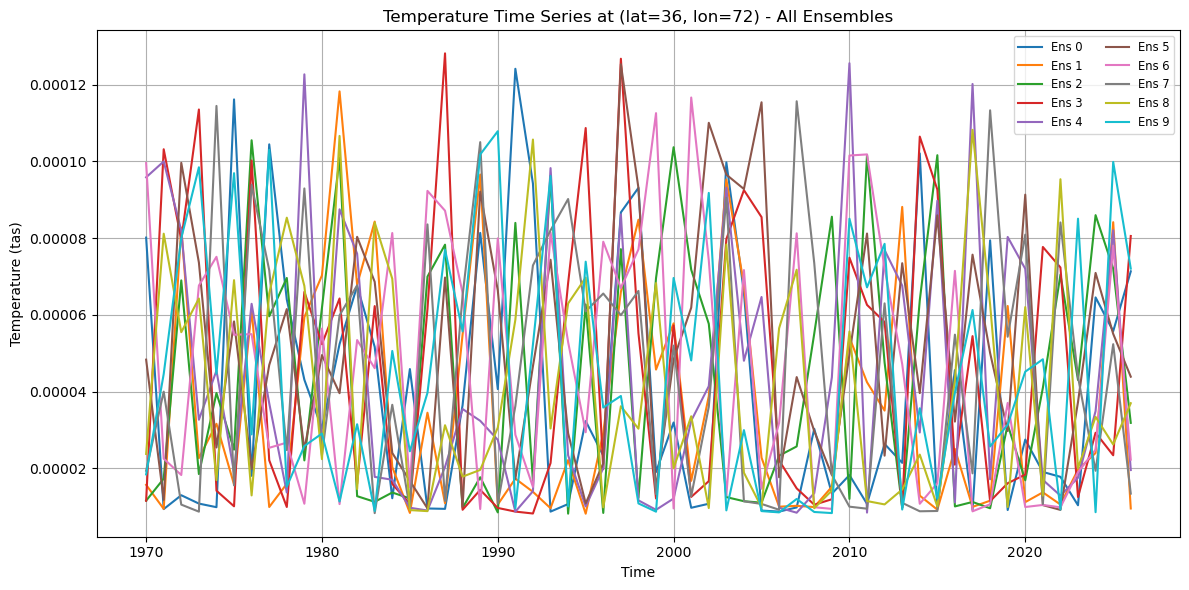

In [21]:
import matplotlib.pyplot as plt

time = all_ensemble_ds.time.values
n_ens = all_ensemble_ds.sizes["ensemble"]  # 또는 n_ens = all_ensemble_ds.ensemble.size

plt.figure(figsize=(12, 6))

for ens in range(n_ens):
    tas_series = all_ensemble_ds.pr[ens, :, 36, 72].values
    plt.plot(time, tas_series, label=f"Ens {ens}")

plt.title("Temperature Time Series at (lat=36, lon=72) - All Ensembles")
plt.xlabel("Time")
plt.ylabel("Temperature (tas)")
plt.legend(ncol=2, fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()
 